# CSC115 Unit 10.3 - NumPy Files 
     
* #### **Today**: 
    - NumPy Files in Python
    - CSV Files<br><br>

    
* #### **This Unit**:
    - 2D arrays
    - 3D arrays
    - Intro to images
    - Arrays and functions
    - File reading
    - Exception Handling<br><br>

    
* #### **Today**: 
    - Unit 10 **reading** and **PreQuiz** out NOW<br><br>

* #### **Upcoming**: 
    - **Lab Adv 6 part B** - AI function writing - due Tonight
    - **Lab Adv 6 part C** - final program - out today
    - <a href="https://sdbor.campuslabs.com/eval-home/">IDEA Surveys Out - % BONUS</a>
        - 60% = +2 bonus
        - 70% = +3 bonus
        - 80% = +4 bonus
        - 90% = +5 bonus
        - 100% = +10 bonus<br><br>

    - **PostQuiz 10** Friday
    - **Exam 3** - Monday April 27
    - ***Final Exam***
        - Monday May 4
        - 10-11:50am
        - Room EEP252/3/4
     
<br>

#### You will need the following files:
* mixed.txt
* mydata.txt
* nums.txt
* nums_missing.txt
* nums_with_header.txt
* strings.txt
* system_data.txt


<!--<hr>

## Shameless Plug!!! - Diwali 2024

<center><img src="https://live.staticflickr.com/3814/10913975736_78fc73239e_c_d.jpg" width=500></center>

#### <a href="https://www.sdsmt.edu/student-life/opportunity-center/international/index.html">Saturday November 23 @ 5pm</a>
* Free Indian Cuisine
* Songs and Dancing
* Fireworks-->

<br>
<hr>
<br>
    


<center><img src ="https://i.postimg.cc/jqh9H7qD/And-Now-For-Something-Completely-Different-Z8-Wfkuk7-subtitled.jpg" width=50%></center>
    
<br>

<font size=5>**Attendance Quiz Password**:  ********* </font>

<br>

<hr>

#### First, let's get our working directory setup

In [1]:
import os

try:
    # works for py files
    print(f"Changing Python directory using '__file__'")
    os.chdir(os.path.dirname(__file__))
    
except Exception as e:
    print(f"   Error: {e}")

    # works for ipynb
    print(f"Trying Jupyter notebook method using '__vsc_ipynb_file__'")
    os.chdir(os.path.dirname(globals()["__vsc_ipynb_file__"]))
finally:
    print(f"CWD: {os.getcwd()}")

Changing Python directory using '__file__'
   Error: name '__file__' is not defined
Trying Jupyter notebook method using '__vsc_ipynb_file__'
CWD: c:\Users\101227284\OneDrive - SDSMT\Software Development I\Unit 10


<br>

## 📂 Getting data from a file with NumPy
We usually work with more data than we want to type in, and there may be many data sets to work with.

<br>

#### NumPy can easily read in data
- Assume a file contains data in the form:  *time*,*data_sample*
    - NOTE: the comma separating the data
- It might look like:

    ```text
    0.00, 1.15
    2.04, 1.25
    4.08, 1.29
    6.02, 1.39
    8.02, 1.26
    ...

    and go on for many more rows
    ```

<br>

#### NumPy offers two easy ways to import data and make it a NumPy array
* We can do quick math, sorting, and plotting from here
* There are two ways:
    - `np.loadtxt( )`
    - `np.genfromtxt( )`<br><br>
* Each has advantages and disadvantages.  We will only focus on `np.loadtxt()`


* See more information here <a href="https://numpy.org/doc/stable/reference/generated/numpy.loadtxt.html"> loadtxt reference</a>

<br>

### 📖 Read with `np.loadtxt()`
* Loads **"delimited"** text into a NumPy array

    > "delimited" means separated by some character - space, comma, tab etc
    * Each row **MUST** have the same number of values
    
    * Default data type is a `float`
    * Can specify another data type
    * If data is missing, does not fill it in

<br><br>

##### Let's open **nums.txt** and take a look

<br><br><br><br>

##### Now read **nums.txt** into a NumPy array

In [2]:
import numpy as np

nums = np.loadtxt('nums.txt', delimiter=',')

print(nums)

[[  1.   4.   5.  21.  34. 100.]
 [ 66.  32.  78.  56.  33.  14.]
 [  9. 100. 167.  45.  33.  11.]]


<br>

#### The default datatype for `np.loadtxt` is **float**
* We will get an error if we don't specify the datatype for non-numbers


* **Take a look at the file "strings.txt"**

In [3]:
# this will give an error
words = np.loadtxt( 'strings.txt', delimiter=',' )

print(words)

ValueError: could not convert string 'arthur' to float64 at row 0, column 1.

<br>

#### Add the `dtype` (datatype) argument.  
`dtype` can be:
* `str`
* `int`
* default is `float`

In [4]:
# read strings.txt as strings
words = np.loadtxt( 'strings.txt', delimiter=',', dtype='str' )

print(words)

[['arthur' 'lancelot' 'galahad']
 ['robin' 'condord' 'bedivere']
 ['patsy' 'tim' 'roger']]


In [5]:
# read nums.txt as ints
nums = np.loadtxt( 'nums.txt', delimiter=',', dtype=int )

print(nums)

[[  1   4   5  21  34 100]
 [ 66  32  78  56  33  14]
 [  9 100 167  45  33  11]]


<br>

#### ⚠️ Remember that the data type in a NumPy array is <u>all the same</u>
* NumPy <u>won't</u> automatically promote here

<br>

* **Look at "mixed.txt"**
    * We must choose the type that encompasses all our data
    * `str` > `float` > `int`

In [6]:
# import mixed values from mixed.txt
mixed = np.loadtxt( 'mixed.txt', delimiter=',', dtype=object )

print(mixed)

[['item' 'index' 'num']
 ['bath soap' '004' '6']
 ['sponge' '042' '14']
 ['toothbrush' '071' '3']
 ['tissues' '013' '18']]


<br><hr><br>

### 🔝 The Data Header
* Sometimes the only text we have in a file is a header.
    * But we just want the numerical data

<br>

* **Look at "nums_with_header.txt"**

In [7]:
# data with header is all strings
data_header = np.loadtxt( 'nums_with_header.txt', delimiter=',', dtype='str' )

print(data_header)

[['left' 'right' 'up' 'down' 'in' 'out']
 ['1' '4' '5' '21' '34' '100']
 ['66' '32' '78' '56' '33' '14']
 ['9' '100' '167' '45' '33' '11']]


<br>

> #### So...we can just skip the header
> * Use the argument `skiprows = num_of_rows_to_skip`

> * Now we can read just the data as floats

In [8]:
# Omit the header by skipping rows
data_no_header = np.loadtxt( 'nums_with_header.txt', skiprows=1, delimiter=',' )

print(data_no_header)

[[  1.   4.   5.  21.  34. 100.]
 [ 66.  32.  78.  56.  33.  14.]
 [  9. 100. 167.  45.  33.  11.]]


<br>

#### Sometimes we just want specific columns
* We can read *individual* columns using `usecols = #`
* Also skip row 1 header
* Notice to read "mixed.txt" we need everything to be a string because of the header and first column


In [9]:
# all columns and header
all_data = np.loadtxt('mixed.txt', delimiter=',', skiprows=1, dtype='str')

print(all_data)

[['bath soap' '004' '6']
 ['sponge' '042' '14']
 ['toothbrush' '071' '3']
 ['tissues' '013' '18']]


<br>

##### Read each column separately
* This allows us to customize the datatypes

In [10]:
# individual columns
itemstr = np.loadtxt('mixed.txt', usecols=0, skiprows=1, delimiter=',', dtype='str')
itemnum = np.loadtxt('mixed.txt', usecols=1, skiprows=1, delimiter=',', dtype='int')
num =     np.loadtxt('mixed.txt', usecols=2, skiprows=1, delimiter=',', dtype='int')

print(itemstr)
print(itemnum)
print(num)
print()

for i in range(np.size(itemstr)):
    print(f"You have {num[i]} {itemstr[i]} with index of {itemnum[i]}")

['bath soap' 'sponge' 'toothbrush' 'tissues']
[ 4 42 71 13]
[ 6 14  3 18]

You have 6 bath soap with index of 4
You have 14 sponge with index of 42
You have 3 toothbrush with index of 71
You have 18 tissues with index of 13


<br>

##### Or we can put similar data in a 2D array
* `usecols` can take a tuple

In [12]:

# individual columns
item = np.loadtxt('mixed.txt', usecols=0, skiprows=1, delimiter=',', dtype='str')
vals = np.loadtxt('mixed.txt', usecols=1, skiprows=1, delimiter=',', dtype='int')

itemnum = vals[:,0]
num = vals[:,1]

print(item)
print(itemnum)
print(num)
print()

for i in range(len(item)):
    print(f"You have {num[i]} {item[i]} with index of {itemnum[i]}")

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

<br>

<hr>

<br>

## 📝 Writing Files with NumPy
* If we can read files, we should also be able to save data to files

* `np.savetxt` is the function to do this
* You normally give it the file name, the 1D or 2D array to save, a format string (C style) and a delimiter.
    - The default format is '%.18e', which means use 18-decimal-place scientific notation
    
    - See more details <a href="https://numpy.org/doc/stable/reference/generated/numpy.savetxt.html#numpy.savetxt">here</a>

        ```python
        np.savetxt(fname, an_array, delimiter=',')   # use default
        np.savetxt(fname, an_array, fmt='%.2f', delimiter=',')
        ```

##### Read "system_data.txt" and take the cos of the array

In [13]:
# load data from txt
data = np.loadtxt('system_data.txt')

# take cos
data2 = np.cos(data)
print(data2)


[[ 1.00000000e+00  4.84872515e-01]
 [ 9.99799204e-01  9.99028442e-01]
 [ 9.99196898e-01  9.51155412e-01]
 [ 9.98193323e-01  2.33965152e-01]
 [ 9.96788882e-01  9.99864880e-01]
 [ 9.94984139e-01  9.73273467e-01]
 [ 9.92779819e-01 -2.73488569e-01]
 [ 9.90176807e-01  8.92759668e-01]
 [ 9.87176149e-01  9.26277124e-01]
 [ 9.83779049e-01 -2.50534669e-01]
 [ 9.79986872e-01  5.83622828e-01]
 [ 9.75801141e-01 -2.68358944e-01]
 [ 9.71223537e-01 -8.54044992e-01]
 [ 9.66255897e-01  8.64914443e-01]
 [ 9.60900218e-01 -2.83055174e-01]
 [ 9.55158649e-01 -9.06199861e-01]
 [ 9.49033497e-01 -8.23147029e-01]
 [ 9.42527221e-01  1.13617327e-01]
 [ 9.35642434e-01  6.42253012e-01]
 [ 9.28381902e-01 -8.86636866e-01]
 [ 9.20748539e-01  9.99588694e-01]
 [ 9.12745412e-01 -9.24832244e-01]
 [ 9.04375734e-01  9.89591152e-01]
 [ 8.95642866e-01  9.30205434e-01]
 [ 8.86550316e-01  4.42127518e-01]
 [ 8.77101735e-01 -9.56863169e-01]
 [ 8.67300918e-01  6.08385030e-02]
 [ 8.57151800e-01  1.43000453e-01]
 [ 8.46658457e-01 -8

<br>

### Use `np.savetxt`
* We can change its output with `fmt`
    * f is for fixed point notation (decimals)
    * d is for "decimal" integers
    * more on `fmt` <a href="https://note.nkmk.me/en/python-numpy-loadtxt-genfromtxt-savetxt/">HERE</a>

In [14]:
# now save this to file

np.savetxt("cos.csv", data2, delimiter=',')   # default scientific notation used
#np.savetxt("cos2.csv", data2, fmt=________, delimiter=',')  # 2 decimal point float

# look in your file browser or the navigation pane for the new file

<br>

<hr>
<br>

<table border=0 width=100%><tr><td bgcolor="green" align=center><font size=5 color=white><b>You Try</b></td></tr></table>

<br>

#### 1. Look at `mydata.txt`
* Does this file have a header?
* How many columns?
* What is the delimiter?
* What is the data type?

<br>

#### 2. Now read the data from "mydata.txt" into a 2D NumPy array
* Ignore(skip) the header rows
* Be sure to use the correct *delimiter* and *datatype*

In [25]:
# read all numeric columns from mydata.txt (after 2 header rows)
mydata = np.loadtxt('mydata.txt', skiprows=2, delimiter=';', dtype=float)

# split into column arrays for plotting
col1 = mydata[:, 0]   # time
col2 = mydata[:, 1]   # sample1
col3 = mydata[:, 2]   # sample2

print(col1)
print(col2)
print(col3)

[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35.
 36. 37. 38. 39. 40. 41. 42. 43. 44. 45. 46. 47. 48. 49. 50. 51. 52. 53.
 54. 55. 56. 57. 58. 59. 60. 61. 62. 63. 64. 65. 66. 67. 68. 69. 70. 71.
 72. 73. 74. 75. 76. 77. 78. 79. 80. 81. 82. 83. 84. 85. 86. 87. 88. 89.
 90. 91. 92. 93. 94. 95. 96. 97. 98. 99.]
[9.00000e+00 3.60000e+01 3.60000e+01 1.00000e+02 1.21000e+02 1.21000e+02
 1.44000e+02 2.89000e+02 3.61000e+02 4.00000e+02 4.41000e+02 6.76000e+02
 7.29000e+02 8.41000e+02 8.41000e+02 1.08900e+03 1.29600e+03 1.52100e+03
 1.68100e+03 2.02500e+03 2.20900e+03 2.40100e+03 2.40100e+03 2.70400e+03
 3.24900e+03 3.72100e+03 4.35600e+03 4.62400e+03 5.32900e+03 5.62500e+03
 5.92900e+03 6.08400e+03 6.08400e+03 7.22500e+03 7.22500e+03 7.56900e+03
 8.10000e+03 8.83600e+03 9.02500e+03 9.40900e+03 9.60400e+03 9.80100e+03
 1.06090e+04 1.21000e+04 1.32250e+04 1.46410e+04 1.48840e+04 1.51290e+04
 1.61290e

<br>

#### 3. From the data use Matplotlib to plot $time$ vs. $sample1$ and $time$ vs. $sample2$
* You will need to slice the arrays to plot them
* Add annotations
    * Label x and y axes
    * Add a legend
    * Add a title
    * Add the grid

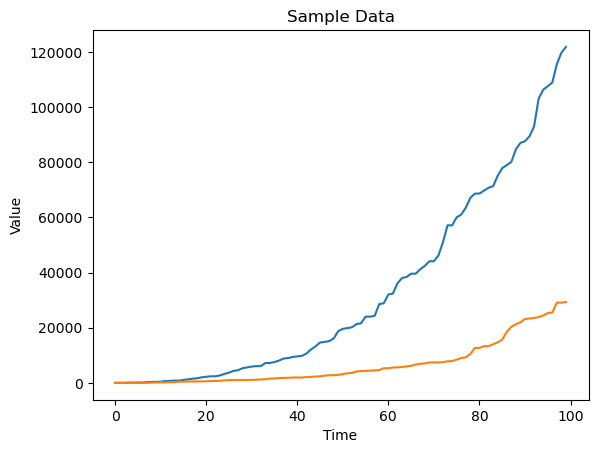

In [26]:
import matplotlib.pyplot as plt

plt.figure()

# slice the column arrays
t = col1
y1 = col2
y2 = col3

# plot the lines
plt.plot(t, y1, label="sample1")
plt.plot(t, y2, label="sample2")

# label the figure
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Sample Data")

# show the plot
plt.show()